# Object Detection + VLMs(Visual Language Models)

⸻

## Contents

1. Setup
    * module import
    * path import
    * util function
2. Configuration
3. VLM Tool
4. Initial detection & Annotated image visualization
5. Critique & Refine the query
6. Second detection
7. Validation
8. Final pipeline

⸻

### 1. Setup 

Module import

In [1]:
# basic module
import os, sys, copy

# data handling / io
import numpy as np
import pandas as pd
import json, base64

# image handling
from PIL import Image, ImageDraw, ImageFont
import cv2 # 박스 그리기/ 좌표 변환 
import torch

# LLM
from openai import OpenAI
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
from PIL import Image, ImageDraw, ImageFont

# Utils
from tqdm import tqdm
import time, argparse, logging, uuid
from dotenv import load_dotenv

c:\Users\KIST\agentic-object-detection\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path import

In [2]:
# 경로/출력 폴더 생성 (나중에 find_project_root() 호출 후 사용)
def ensure_dir(path):
    # 디렉토리 없으면 생성
    os.makedirs(path, exist_ok=True)

def get_project_path(*paths):
    project_root = os.getcwd()    # or use a specific absolute path if needed
    return os.path.join(project_root, *paths)


Util function

In [3]:
# project root 
def find_project_root(marker_filename=".project-root"):
    current_dir = os.path.abspath(os.getcwd())
    while True:
        if os.path.isfile(os.path.join(current_dir, marker_filename)):
            return current_dir
        parent_dir = os.path.dirname(current_dir)
        if parent_dir == current_dir:
            raise FileNotFoundError(f"Could not find {marker_filename} in any parent directory.")
        current_dir = parent_dir

In [4]:
# b64 encoder: jpg image -> base64 string / VLM API
def encode_image_to_base64(img_path):
    try: 
        with open(img_path, "rb") as image_file:
            return base64.b64encode(image_file.read()).decode("utf-8")
    except Exception as e:
        print(f"Error encoding image.: {e}")
        return None

In [5]:
# example: base64 encoding
input_img_path = os.path.join(os.getcwd(), "data_notebook", "i_0.jpg")
output_img_path = os.path.join(os.getcwd(), "output_notebook", "o_0.jpg")

b64str = encode_image_to_base64(input_img_path) 
print("인코딩 문자열의 앞 50자: ")
print(b64str[:50]) 

인코딩 문자열의 앞 50자: 
/9j/4AAQSkZJRgABAQEBLAEsAAD/7Sm+UGhvdG9zaG9wIDMuMA


In [6]:
# 화살표, 숫자 표시
def draw_arrows_and_numbers(image_path, detected_objects):
    """
    Draws arrows and numbers on an image to label detected objects.
    """
    img = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
    font = cv2.FONT_HERSHEY_SIMPLEX
    used_positions = []

    # Pad the image with a white border
    top, bottom, left, right = 50, 50, 50, 50
    img = cv2.copyMakeBorder(img, top, bottom, left, right, cv2.BORDER_CONSTANT, value=[255, 255, 255])

    height, width, _ = img.shape

    for i, (num, obj, box) in enumerate(detected_objects):
        x1, y1, x2, y2 = map(int, box)
        cx, cy = (x1 + x2) // 2, (y1 + y2) // 2  # Center of the bounding box

        # Adjust coordinates for padded image
        x1 += left
        y1 += top
        x2 += left
        y2 += top
        cx += left
        cy += top

        # Determine arrow direction towards the nearest border
        distances = {'top': cy, 'bottom': height - cy, 'left': cx, 'right': width - cx}
        direction = min(distances, key=distances.get)

        if direction == 'top':
            arrow_end = (cx, top)
            text_position = (cx - 10, top - 10)
        elif direction == 'bottom':
            arrow_end = (cx, height - bottom)
            text_position = (cx - 10, height - 5)
        elif direction == 'left':
            arrow_end = (left, cy)
            text_position = (left - 30, cy + 5)
        else:
            arrow_end = (width - right, cy)
            text_position = (width - 30, cy + 5)

        # Draw the dashed arrow from the object center to the border
        color = (0, 0, 0)  # Black color for all arrows
        line_type = cv2.LINE_4
        cv2.arrowedLine(img, (cx, cy), arrow_end, color, 2, tipLength=0.3)

        # Draw a semi-transparent rectangle behind the text
        overlay = img.copy()
        cv2.rectangle(overlay, (text_position[0] - 5, text_position[1] - 20), (text_position[0] + 30, text_position[1] + 5), (0, 0, 0), -1)
        alpha = 0.5
        cv2.addWeighted(overlay, alpha, img, 1 - alpha, 0, img)

        # Draw the number at the border with black text
        cv2.putText(img, str(num), text_position, font, 0.5, color, 2)

    # Create dynamic output path based on input image path
    base_name = os.path.basename(image_path)
    name_part, ext_part = os.path.splitext(base_name)
    output_filename = f"labeled_objects_{name_part}{ext_part}"
    
    # Correctly construct the path relative to the notebook's location
    output_dir = os.path.join(os.getcwd(), "output_notebook")
    os.makedirs(output_dir, exist_ok=True)
    labeled_image_path = os.path.join(output_dir, output_filename)
    
    cv2.imwrite(labeled_image_path, img)
    return labeled_image_path

In [7]:
# 직사각형 표시
def draw_rounded_rectangle(draw, box, radius, outline, width):
    x1, y1, x2, y2 = box
    draw.rectangle([x1 + radius, y1, x2 - radius, y2], outline=outline, width=width)

In [8]:
# 바운딩 박스 표시
def draw_bounding_boxes(image_path, filtered_objects):
    # Open the image
    final_img = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(final_img)
    font = ImageFont.truetype("arial.ttf", 20)

    for num, lbl, box in filtered_objects:
        x1, y1, x2, y2 = box
        box_width = x2 - x1
        box_height = y2 - y1

        # Define styles
        outline_color = "red"
        outline_width = 3
        radius = 10  # Radius for rounded corners
        label_fill_color = (255, 0, 0, 128)  # Semi-transparent red
        text_color = "white"
        padding = 5

        # Draw rounded rectangle for bounding box
        draw.rounded_rectangle([x1, y1, x2, y2], radius=radius, outline=outline_color, width=outline_width)

        # Calculate text size
        left, top, right, bottom = draw.textbbox((0, 0), lbl, font=font)
        text_width = right - left
        text_height = bottom - top

        # Position for label box
        label_box = [x1, y1 - text_height - 2 * padding, x1 + text_width + 2 * padding, y1]

        # Draw label box
        draw.rectangle(label_box, fill=label_fill_color)

        # Draw text
        text_position = (x1 + padding, y1 - text_height - padding)
        draw.text(text_position, lbl, fill=text_color, font=font)

    return final_img

⸻

### 2. Configuration

In [9]:
# === Configuration ===

# 1. 입력 이미지 경로, 출력 디렉토리 지정
input_img_path = os.path.join(os.getcwd(), "data_notebook", "i_0.jpg")
output_img_path = os.path.join(os.getcwd(), "output_notebook", "o_0.jpg")


# 2. detectcor / device/ threshold / 최대 박스 수
MODEL_TYPES = {
    "owlvit": "google/owlvit-base-patch32",
    "grounding_dino": "IDEA-Research/grounding-dino-tiny",} # 모델 로드
DEFAULT_MODEL_TYPE = "grounding_dino"
MODEL_ID = MODEL_TYPES[DEFAULT_MODEL_TYPE]
INV_MODEL_TYPES = {v:k for k,v in MODEL_TYPES.items()} # 모델 별칭 딕셔너리

# device config
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# detection config
CONFIDENCE_THRESHOLD = 0.2
MAX_BOXES = 20


# 3. VLM 모델명(개념 추출: gpt-4o, 질의 비평: o1, 최종 검증: gpt-4o), 토큰/온도 등
CONCEPT_EXTRACTION_VLM = "gpt-4.1"  # 초기 개념 추출
CRITIQUE_VLM = "gpt-4o"            # 쿼리 비평 및 개선
VALIDATION_VLM = "gpt-4.1"         # 최종 검증


# 4. 숫자 라벨/ 패딩 옵션, 폰트/두께, 색
COLOR_PALETTE = [
    "red", "blue", "green", "purple", "orange", 
    "cyan", "magenta", "yellow", "brown", "pink"]
FONT_PATH = "fonts/arial.ttf"

IMAGE_EXTENSIONS = ("jpg", "jpeg", "png")
DRAW_FONT_SIZE = 22
DRAW_LABEL_LANG = "en"      # 'en' or 'ko'

LABEL_BOX_COLOR = "red"
LABEL_FONT_SIZE = 18
LABEL_LINE_WIDTH = 3

# 5. chatGPT API key
project_root = find_project_root()
dotenv_path = os.path.join(project_root, ".env")


⸻

### 3. VLM Tool

* Input
    * Image(path/ base64)
    * User request
* Output
    * Object: [str]

In [10]:
# === VLM Tool ===
class VLMTool:
    def __init__(self, api_key):
        self.client = OpenAI(api_key=api_key)

In [11]:
# 1. chat completion: VLM API 요청, 응답 저장
def model_response(self, messages, model="gpt-4.1", temperature=0.1, max_tokens=1000, response_format=None):
    try: 
        # === 텍스트 생성 요청 ===
        if model in ["gpt-4.1", "gpt-4o"]:
            response = self.client.chat.completions.create(
                model=model,
                messages=messages,
                max_completion_tokens=max_tokens,
                response_format=response_format if response_format else {"type": "text"},
                temperature=temperature
            ) # open ai class method
        else: 
            raise NotImplementedError("This model is not supported")
        
        # === 응답 추출 ===
        return response.choices[0].message.content # open ai 응답 메시지 리스트 중 첫 번쨰 답변만

    except Exception as e:
        print(f"Error calling LLM: {e}")
        return None
VLMTool.model_response = model_response

# 2. extract objects from request: 탐지 객체 목록 문자열 리스트로 추출
def extract_objects_from_request(self, image_path, user_text, model="gpt-4.1"):
    try:
        # === image encoding ===
        base64_image = encode_image_to_base64(image_path)
        if not base64_image:
            return None

        # === prompt ===
        prompt = (
            "You are an AI assistant that identifies the primary subject for an object detection task from a user's request. "
            "Your goal is to extract ONLY the main object(s) the user wants to find, including their specific attributes like color or state. "
            "Pay close attention to the grammar. If an object is mentioned as part of a location or relationship (e.g., 'the cat on the chair', 'tomatoes hidden by leaves'), do NOT extract the contextual object (like 'chair' or 'leaves'). Extract only the primary subject of the request."
            "If the user asks to find 'all objects' or makes a similarly broad request, you must carefully analyze the provided image and return a comma-separated list of all distinct objects you can identify. For example, if the image shows tomatoes on a vine, a good response would be 'tomatoes, tomato vine, leaves'."
            "Respond ONLY with a comma-separated list of the primary objects and NOTHING ELSE."
            "For example, for 'Find the red tomatoes hidden by leaves', you should respond with 'red tomatoes'."
            "For 'Show me the dog on the bed', you should respond with 'dog'."
        )

        # === messages: multi modal ===
        messages = [
            {"role": "system", "content": prompt},
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": user_text},
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": f"data:image/jpeg;base64,{base64_image}",
                            "detail": "high"
                        }
                    }
                ]
            }
        ]
        
        # === VLM 응답 결과 ===
        result = self.model_response(messages, model=model)

        # === 리스트 생성 ===
        if result:
            detected_objects = [obj.strip().lower() for obj in result.split(",") if obj.strip()]
            return detected_objects
    
    except Exception as e:
        print(f"Error extracting objects from request: {e}")
        return None
VLMTool.extract_objects_from_request = extract_objects_from_request

VLMTool example

Image


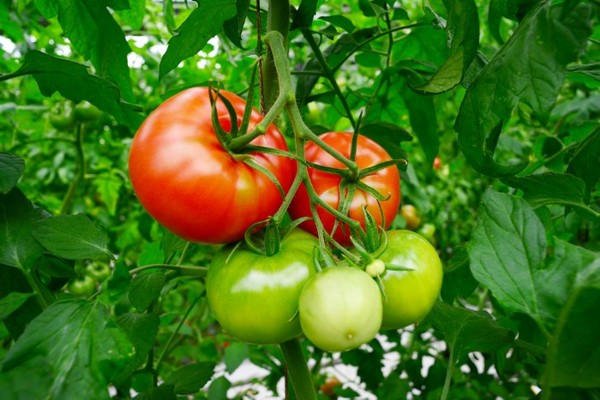

In [12]:
print("Image")
display(Image.open(input_img_path))

In [13]:
# fig & initialize VLM Tool
load_dotenv()
api_key = os.getenv("OPENAI_API_KEY")
vlm_tool = VLMTool(api_key=api_key)

# example 1: 모든 객체 탐지
image_path_1 = input_img_path
user_request_1 = "Find all objects in this picture."

img_b64 = encode_image_to_base64(image_path_1)
message1 = [
    {
        "role": "system", 
        "content": "You are an AI assistant that identifies the primary subject for an object detection task from a user's request."},
    {  
        "role": "user", 
        "content": [
            {"type": "text", "text": user_request_1}, 
            {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{img_b64}", "detail": "high"}}]}
]

result = vlm_tool.model_response(message1)
object_1 = vlm_tool.extract_objects_from_request(image_path_1, user_request_1)
print("[Message1] ", f"{result}")
print("\n")
print("[User Request1]: ", f"{user_request_1}")
print("[Detected Object1]: ", f"{object_1}")
print("\n")

# example 2: 토마토의 색 탐지
image_path_2 = input_img_path
user_request_2 = "Find tomatoes's color."
object_2 = vlm_tool.extract_objects_from_request(image_path_2, user_request_2)
print("[User Request2]: ", f"{user_request_2}")
print("[Detected  Object2]: ", f"{object_2}")

[Message1]  The primary objects in this picture are:

1. Tomatoes (at different stages of ripeness: red, green, and light green)
2. Tomato plant stems
3. Tomato plant leaves

The main focus is on the cluster of tomatoes growing on the plant.


[User Request1]:  Find all objects in this picture.
[Detected Object1]:  ['tomatoes', 'tomato vine', 'leaves']


[User Request2]:  Find tomatoes's color.
[Detected  Object2]:  ['red', 'green', 'light green']


⸻

### 4. Initial detection & Annotated image visualization

✅ 1단계: Object Detection (원본 이미지 + 개념 리스트 → 박스, 점수, 라벨)
* Input
    * Image
    * Object labels
* Output - 중간 결과
    * detection: [{bbox, score, label}]

✅ 2단계: Annotated Image 생성 (o_grad 추론 → conf/iou 필터 → 픽셀 좌표 → 시각화)
* Input
    * Image
    * initial_detection
* Output
    * annotated_image


In [14]:
class ObjectDetectionTool:
    def __init__(self, model_id, device, vlm_tool, confidence_threshold=0.2, concept_detection_model="gpt-4.1", initial_critique_model="gpt-4o", final_critique_model="gpt-4.1"):
        self.model_id = model_id # owlvit or groungding dino
        self.processor = AutoProcessor.from_pretrained(model_id) # 모델 전처리, 후처리 - 입력 포맷
        self.model = AutoModelForZeroShotObjectDetection.from_pretrained(model_id).to(device) # 제로샷 추론 모델 
        self.device = device 
        self.vlm_tool = vlm_tool
            
        self.confidence_threshold = confidence_threshold
        self.concept_detection_model = concept_detection_model
        self.initial_critique_model = initial_critique_model
        self.final_critique_model = final_critique_model

        # store bounding boxes for potential usage later (e.g., for SAM).
        self.last_detection_bboxes = []
        self.last_filtered_objects = []

In [15]:
def _run_detector_debugging(self, image_path, query_list):
    """
    input: image, object query(label)
    output: initial_detection[{bbox, score, label}]
    """
    # === 모델에 맞게 쿼리 수정 === 
    # grounding_dino: "cat. dog. person." 마침표로 구분된 문자열
    if INV_MODEL_TYPES[self.model_id] == "grounding_dino":
        formatted_queries = " ".join([f"{q}." for q in list(query_list)])
    # owl-vit: "An image of {q}", 텍스트 프롬프트 
    elif INV_MODEL_TYPES[self.model_id] == "owlvit":
        formatted_queries = [f"An image of {q}" for q in query_list] 
    else:
        raise NotImplementedError("Model not supported")
    
    # === image load === 
    # PIL Image, rgb format
    img = Image.open(image_path).convert("RGB") 

    # === input preprocess ===
    inputs = self.processor(
        text=formatted_queries,
        images=img,
        return_tensors="pt", # pytorch tensor
        padding=True,
        truncation=True
    ).to(self.device) # model input format

    # === model inferences === 
    self. model.eval()
    with torch.no_grad():
        outputs = self.model(**inputs)

    # === model input debugging ===
    print("===Input Debugging===")
    print("Formatted queries:", formatted_queries) 
    print("Image size:", img.size) # (width, height)
    print("Inputs keys:", inputs.keys())

    for k, v in inputs.items():
        print(f"{k}: shape={v.shape}, dtype={v.dtype}")
    
    # === model output debugging ===
    print("===Raw Output Debugging===")
    print("Raw model outputs:", outputs)
    print()

    
    # === Result Post-processing: bounding boxes === 
    # grounding dino: CLIP-style query-text alignment 기반, tokenied text(input_ids) 와 logits 비교
    if INV_MODEL_TYPES[self.model_id] == "grounding_dino":
        results = self.processor.post_process_grounded_object_detection(
            outputs,
            inputs.input_ids,
            target_sizes=[img.size[::-1]]
        )
        boxes = results[0]["boxes"]
        scores = results[0]["scores"]
        labels = results[0]["text_labels"]
    # owl-vit: 토큰 매칭 없이 logits max, [num_boxes, num_queries] - soft matching
    elif INV_MODEL_TYPES[self.model_id] ==  "owlvit": 
        logits = torch.max(outputs["logits"][0], dim=-1)
        scores = torch.sigmoid(logits.values).cpu().numpy()
        label_indices = logits.indices.cpu().numpy()
        
        # ✅ FIX 1: 인덱스를 실제 레이블 텍스트로 매핑
        labels = [query_list[idx] for idx in label_indices]
        
        # pred_boxes는 normalized coordinates [0, 1] (center_x, center_y, width, height)
        boxes_cxcywh = outputs["pred_boxes"][0].cpu().numpy()

        # ✅ FIX 2: (center_x, center_y, width, height) → (x1, y1, x2, y2) 변환
        img_w, img_h = img.size
        boxes = np.zeros_like(boxes_cxcywh)
        boxes[:, 0] = (boxes_cxcywh[:, 0] - boxes_cxcywh[:, 2] / 2) * img_w  # x1
        boxes[:, 1] = (boxes_cxcywh[:, 1] - boxes_cxcywh[:, 3] / 2) * img_h  # y1
        boxes[:, 2] = (boxes_cxcywh[:, 0] + boxes_cxcywh[:, 2] / 2) * img_w  # x2
        boxes[:, 3] = (boxes_cxcywh[:, 1] + boxes_cxcywh[:, 3] / 2) * img_h  # y2

    else:
        raise NotImplementedError("Model not supported")

    # === Result Debugging === 
    print("===Result Debugging===")
    for i in range(len(boxes)):
        print(f"Box {i}: score={scores[i]:.4f}, label={labels[i]}, box={boxes[i]}")


    # === Result Post-processing: confidence thresholding === 
    # filter condition: score
    detected_objects_final = []
    idx = 1
    for score, box, label in zip(scores, boxes, labels):
        if score < self.confidence_threshold:
            continue
        detected_objects_final.append((idx, label, box.tolist()))
        idx += 1

    # === Draw arrows and numbers ===
    labeled_image_path = draw_arrows_and_numbers(image_path, detected_objects_final)

    # === Final result debugging ===
    print("\n=== Confidence threshold 이상 객체 ===")
    for idx, label, box in detected_objects_final:
        print(f"[{idx}] label: {label}, box: {box}")

    print(f"\n라벨링 이미지 저장 위치: {labeled_image_path}")
    return detected_objects_final, labeled_image_path
ObjectDetectionTool._run_detector_debugging = _run_detector_debugging
    

Example 1: 모든 객체 탐지 / grounding-dino model

* 이미지–텍스트 입력 기반 Zero-Shot Object Detectio Input/ Rawoutput/ Output 포함
* (AutoProcessor & AutoModel Inference)

VLM 추출 결과: ['tomatoes', 'tomato vine', 'leaves']


c:\Users\KIST\agentic-object-detection\.venv\Lib\site-packages\transformers\models\bert\modeling_bert.py:413: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:555.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(


===Input Debugging===
Formatted queries: tomatoes. tomato vine. leaves.
Image size: (600, 400)
Inputs keys: KeysView({'pixel_values': tensor([[[[-2.1179, -2.1008, -2.0837,  ..., -1.3473, -1.3473, -1.3473],
          [-2.1179, -2.1008, -2.0665,  ..., -1.4158, -1.3987, -1.3987],
          [-2.1008, -2.0837, -2.0494,  ..., -1.5528, -1.5185, -1.5014],
          ...,
          [-1.6384, -1.6384, -1.6213,  ..., -1.9124, -1.9809, -1.9980],
          [-1.6555, -1.6555, -1.6384,  ..., -1.8953, -1.9638, -1.9980],
          [-1.6555, -1.6555, -1.6384,  ..., -1.8953, -1.9638, -1.9980]],

         [[-0.3901, -0.3550, -0.3025,  ..., -0.4076, -0.4076, -0.4076],
          [-0.3550, -0.3200, -0.2850,  ..., -0.4776, -0.4601, -0.4601],
          [-0.2850, -0.2675, -0.2500,  ..., -0.6352, -0.5826, -0.5826],
          ...,
          [-0.4601, -0.4601, -0.4426,  ..., -0.9503, -1.0203, -1.0378],
          [-0.4776, -0.4776, -0.4601,  ..., -0.9328, -1.0028, -1.0378],
          [-0.4776, -0.4776, -0.4601,  ...

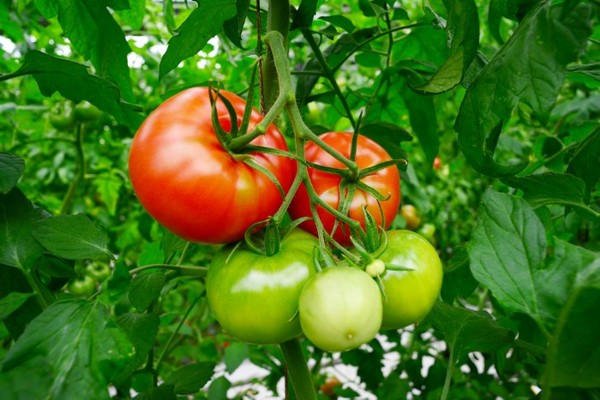


Annotated image:


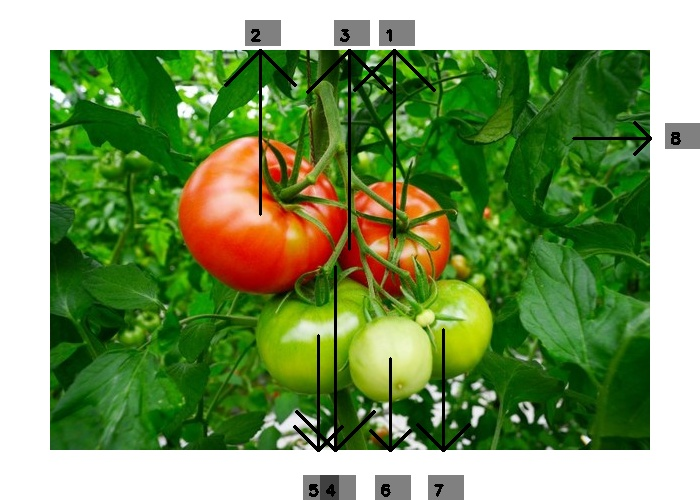

In [16]:
# === 모든 객체 탐지 / detection model: grounding-dino ===

# VLM Tool 초기화
load_dotenv()
api_key = os.getenv("OPENAI_API_KEY")
vlm_tool = VLMTool(api_key=api_key)

# ObjectDetectionTool 초기화
detector = ObjectDetectionTool(
    model_id=MODEL_ID,  # grounding-dino
    device=DEVICE,      
    vlm_tool=vlm_tool,
    confidence_threshold=CONFIDENCE_THRESHOLD,  # 0.2
    concept_detection_model="gpt-4.1",
    initial_critique_model="gpt-4o",
    final_critique_model="gpt-4.1"
)

# === 테스트 입력 ===
# 이미지 및 사용자 요청
image_path = input_img_path
user_request = "Find all the visible objects in the greenhouse image."

# === VLM으로 객체 후보 추출 ===
query_list = vlm_tool.extract_objects_from_request(image_path, user_request)
print("VLM 추출 결과:", query_list)

# === Detection ===
detected_objects, labeled_image_path = detector._run_detector_debugging(image_path, query_list)
print(f"Number of detected object: {len(detected_objects)}")
print(f"Labeled image: {labeled_image_path}")
print(f"Final detections:")
for num, label, bbox in detected_objects:
    x1, y1, x2, y2 = bbox
    print(f"  [{num}] label: {label}, box: ({x1:.1f}, {y1:.1f}, {x2:.1f}, {y2:.1f})")

# === Visualization === 
# 원본 이미지
print("Original image:")
original_img = Image.open(image_path)
display(original_img)

# 탐지 결과 이미지
print("\nAnnotated image:")
labeled_img = Image.open(labeled_image_path)
display(labeled_img)


Example 2:  일부 객체 탐지 / owl-vit model

VLM 추출 결과: ['red tomatoes']
===Input Debugging===
Formatted queries: ['An image of red tomatoes']
Image size: (600, 400)
Inputs keys: KeysView({'input_ids': tensor([[49406,   550,  2867,   539,   736, 13004, 49407]], device='cuda:0'), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1]], device='cuda:0'), 'pixel_values': tensor([[[[-1.7923, -1.7631, -1.7047,  ..., -1.1353, -1.1207, -1.1207],
          [-1.7923, -1.7631, -1.7047,  ..., -1.2229, -1.1791, -1.1645],
          [-1.7777, -1.7339, -1.7047,  ..., -1.4127, -1.3105, -1.2667],
          ...,
          [-1.3835, -1.3689, -1.3689,  ..., -1.5587, -1.6317, -1.6901],
          [-1.3981, -1.3835, -1.3835,  ..., -1.5441, -1.6171, -1.6901],
          [-1.3981, -1.3835, -1.3835,  ..., -1.5295, -1.6171, -1.6901]],

         [[-0.3564, -0.2813, -0.2213,  ..., -0.3264, -0.3414, -0.3414],
          [-0.3114, -0.2663, -0.2213,  ..., -0.4164, -0.4014, -0.3864],
          [-0.2513, -0.2213, -0.2063,  ..., -0.6115, -0.5515, -0.5065],
          ...,
 

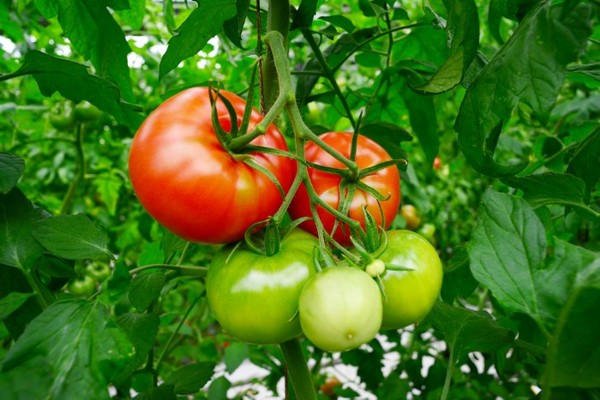


Annotated image:


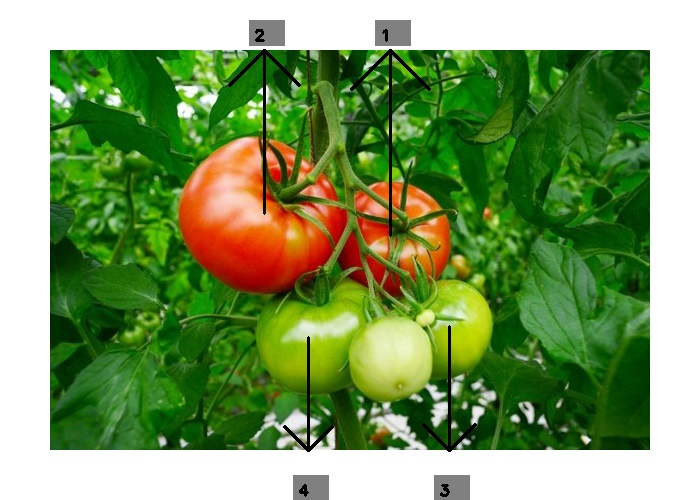

In [17]:
# ===  일부 객체 탐지 / owl-vit model ===
# VLM Tool 초기화
load_dotenv()
api_key = os.getenv("OPENAI_API_KEY")
vlm_tool = VLMTool(api_key=api_key)

# ObjectDetectionTool 초기화
detector = ObjectDetectionTool(
    model_id = MODEL_TYPES["owlvit"],
    device=DEVICE,
    vlm_tool=vlm_tool,
    confidence_threshold=CONFIDENCE_THRESHOLD,  # 0.2
    concept_detection_model="gpt-4.1",
    initial_critique_model="gpt-4o",
    final_critique_model="gpt-4.1"
)

# === 테스트 입력 ===
# 이미지 및 사용자 요청
image_path = input_img_path
user_request = "Find red colored tomatoes in this image."

# === VLM으로 객체 후보 추출 ===
query_list = vlm_tool.extract_objects_from_request(image_path, user_request)
print("VLM 추출 결과:", query_list)

# === Detection ===
detected_objects, labeled_image_path = detector._run_detector_debugging(image_path, query_list)
print(f"Number of detected object: {len(detected_objects)}")
print(f"Labeled image: {labeled_image_path}")
print(f"Final detections:")
for num, label, bbox in detected_objects:
    x1, y1, x2, y2 = bbox
    print(f"  [{num}] label: {label}, box: ({x1:.1f}, {y1:.1f}, {x2:.1f}, {y2:.1f})")

# === Visualization === 
# 원본 이미지
print("Original image:")
original_img = Image.open(image_path)
display(original_img)

# 탐지 결과 이미지
print("\nAnnotated image:")
labeled_img = Image.open(labeled_image_path)
display(labeled_img)


=== Debugging ===

* Model: Owl ViT 

* Inputs keys: KeysView({'input_ids', 'attention_mask', 'pixel_values'})
    * input_ids
        * query -> tokenize -> index(BERT format)
        * 각 행이 하나의 쿼리 문장
        * 토크나이저가 문장을 단어 단위로 분해한 후 사전에 매칭한 token
        * ```python
            'input_ids': 
                tensor([
                    [49406,   550,  2867,   539,  9867, 49407],  # An image of tomato
                    [49406,   550,  2867,   539,  7232, 49407],  # An image of leaf
                    [49406,   550,  2867,   539,  6761, 49407]   # An image of stem
                ])
            ```

    * attention_mask
        * padding 0, valid token 1 -> masked vector
        * ```python
            'attention_mask':
                tensor([
                    [1, 1, 1, 1, 1, 1], # An image of tomato
                    [1, 1, 1, 1, 1, 1], # An image of leaf
                    [1, 1, 1, 1, 1, 1] # An image of stem
                ])
            ```

    * pixel_values
        * VLM에 입력되는 이미지 데이터 - 전처리되어 모델이 학습한 형식에 맞춘 텐서
        * tensor [batch, channel, height, width]: ([1, 3, 768, 768])
        * 한 장의 RGB 이미지를 768*768 크기로 바꿔서 입력으로 사용
        * 이미지의 픽셀을 [-1, 1] 범위로 정규화
        * ```python
            'pixel_values': tensor([[[[
                -0.9164, -0.9164, -0.9164,  ..., -1.2083, -1.1791, -1.1499],
                [-0.9018, -0.9018, -0.9018,  ..., -1.1937, -1.1791, -1.1645],
                [-0.9164, -0.9018, -0.8872,  ..., -1.2083, -1.2083, -1.2083],
                ...,
                [-1.3981, -1.3689, -1.3543,  ..., -1.2959, -1.2959, -1.2959],
                [-1.3981, -1.3981, -1.3689,  ..., -1.2959, -1.2959, -1.3105],
                [-1.3543, -1.3543, -1.3543,  ..., -1.2813, -1.2959, -1.3251]
            ]]])
            ```

* Raw output 
    * zero-shot object detection을 수행한 결과
    * 다양한 필드의 텐서를 포함한 구조체

* Output
    * 
    * confidence 이상 객체

owlvit model: 쿼리가 추상적이거나 길 경우 정확하게 매핑하지 못할 수 있음. red에 반응하지 못하거나 tomato만 학습될 수 있음

In [18]:
def _run_detector(self, image_path, query_list):
    """
    input: image, object query(label)
    output: initial_detection[{bbox, score, label}]
    """
    # === 모델에 맞게 쿼리 수정 === 
    # grounding_dino: "cat. dog. person." 마침표로 구분된 문자열
    if INV_MODEL_TYPES[self.model_id] == "grounding_dino":
        formatted_queries = " ".join([f"{q}." for q in list(query_list)])
    # owl-vit: "An image of {q}", 텍스트 프롬프트 
    elif INV_MODEL_TYPES[self.model_id] == "owlvit":
        formatted_queries = [f"An image of {q}" for q in query_list] 
    else:
        raise NotImplementedError("Model not supported")
    
    # === image load === 
    # PIL Image, rgb format
    img = Image.open(image_path).convert("RGB") 

    # === input preprocess ===
    inputs = self.processor(
        text=formatted_queries,
        images=img,
        return_tensors="pt", # pytorch tensor
        padding=True,
        truncation=True
    ).to(self.device) # model input format

    # === model inferences === 
    self. model.eval()
    with torch.no_grad():
        outputs = self.model(**inputs)

    # === Result Post-processing: bounding boxes === 
    # grounding dino: CLIP-style query-text alignment 기반, tokenied text(input_ids) 와 logits 비교
    if INV_MODEL_TYPES[self.model_id] == "grounding_dino":
        results = self.processor.post_process_grounded_object_detection(
            outputs,
            inputs.input_ids,
            target_sizes=[img.size[::-1]]
        )
        boxes = results[0]["boxes"]
        scores = results[0]["scores"]
        labels = results[0]["text_labels"]
    # owl-vit: 토큰 매칭 없이 logits max, [num_boxes, num_queries] - soft matching
    elif INV_MODEL_TYPES[self.model_id] ==  "owlvit": 
        logits = torch.max(outputs["logits"][0], dim=-1)
        scores = torch.sigmoid(logits.values).cpu().numpy()
        label_indices = logits.indices.cpu().numpy()
        
        # ✅ FIX 1: 인덱스를 실제 레이블 텍스트로 매핑
        labels = [query_list[idx] for idx in label_indices]
        
        # pred_boxes는 normalized coordinates [0, 1] (center_x, center_y, width, height)
        boxes_cxcywh = outputs["pred_boxes"][0].cpu().numpy()

        # ✅ FIX 2: (center_x, center_y, width, height) → (x1, y1, x2, y2) 변환
        img_w, img_h = img.size
        boxes = np.zeros_like(boxes_cxcywh)
        boxes[:, 0] = (boxes_cxcywh[:, 0] - boxes_cxcywh[:, 2] / 2) * img_w  # x1
        boxes[:, 1] = (boxes_cxcywh[:, 1] - boxes_cxcywh[:, 3] / 2) * img_h  # y1
        boxes[:, 2] = (boxes_cxcywh[:, 0] + boxes_cxcywh[:, 2] / 2) * img_w  # x2
        boxes[:, 3] = (boxes_cxcywh[:, 1] + boxes_cxcywh[:, 3] / 2) * img_h  # y2

    else:
        raise NotImplementedError("Model not supported")

    # === Result Post-processing: confidence thresholding === 
    # filter condition: score
    detected_objects_final = []
    idx = 1
    for score, box, label in zip(scores, boxes, labels):
        if score < self.confidence_threshold:
            continue
        detected_objects_final.append((idx, label, box.tolist()))
        idx += 1

    # === Draw arrows and numbers ===
    labeled_image_path = draw_arrows_and_numbers(image_path, detected_objects_final)
    return detected_objects_final, labeled_image_path

ObjectDetectionTool._run_detector = _run_detector
    

⸻

### 5. Critique & Refine the query

* initial detection의 결과가 미미할 때 '선택적'으로 '추가 연산'
* User request가 세분화된 라벨이라면 bbox가 threshold를 넘을 수 없으므로 해당 문제를 해결하기 위한 방식

* Input
    * annotated image(conclude arrow & numbered label) 
    * User request
    * initial detection

* Process
    * 실패한 케이스에 대하여 라벨이 구체적인지를 질문
    * 하의어를 포함하는 상의어로 변경 ex. 나뭇잎에 가려진 토마토 -> 토마토

* Output
    * refined concept
    - {"reasoning": "...", "refined_list": "dog, shoe, flower"} 같은 JSON


In [19]:
# === Critique/Refine ===
# “너무 구체/오분류 라벨→상위 개념 일반화”를 요청

def _critique_and_refine_query_debuging(self, user_request, original_concepts, labeled_image_path, objects_detected, model = 'gpt-4o'):
    """
    input: annotated image, user_request, initial detection
    output: refined concept
    """
    try: 
        # === image encoding ===
        base64_labeled_image = encode_image_to_base64(labeled_image_path)
        if not base64_labeled_image:
            return None
        
        # === refined_messages ===
        refined_messages = [
            {
                "role": "system", 
                "content": """
                    You are an AI system that refines detection queries. 
                    You are provided with the outputs from an object detection model, along with the user's request and the objects from the user's request that were extracted and provided to the object detection model.
                    Your task is to analyze whether the object detector has extracted the results properly to the user's request and, if not, refine the queries by generalizing concepts where possible.
                    
                    Important guidelines:
                    1. If the detection results are already good, no need to refine. 
                    - In that case, provide reasoning indicating no refinement was necessary and return the same list.
                    2. If the detection results are poor or null, propose synonyms or more generic categories and explain why. Wherever possible, retain the singular version of the concept.
                    3. Return your final answer as a JSON object with exactly two fields: "reasoning" and "refined_list".
                    - "reasoning" is a short explanation of why you refined or didn't refine.
                    - "refined_list" is a comma-separated list of object names that should be re-tried in detection.
                    4. Output ONLY the JSON, and no other text.

                    Below are some examples:

                    EXAMPLE 1
                    User's Request: Detect the teacup poodle
                    Original concept: "Teacup poodle"

                    Final output:
                    {
                    "reasoning": "The provided image does not have any detections for the concept of teacup poodle. The concept "teacup poodle" might be a very specific concept for the model to detect. This could  be refined to a more higher-level and generic concept like 'Dog',
                    "refined_list": "dog"
                    }

                    EXAMPLE 2
                    User's Request: Detect the sparkly stiletto shoe
                    Original concept: "Sparkly stiletto shoe"

                    Final output:
                    {
                    "reasoning": "The provided image does not specific detections that correspond for 'Sparkly stiletto shoe'. 'Sparkly stiletto shoe' might be too specific for the model. Refining to 'shoe', a more generic concept might increase the likelihood of detection.",
                    "refined_list": "shoe"
                    }

                    EXAMPLE 3
                    User's Request: Detect the hydrangea
                    Original concept: "Hydrangea"

                    Final output:
                    {
                    "reasoning": "No detections found for 'hydrangea'. The model might struggle with specific flower types. Refining to the more general concept 'flower' could yield better results.",
                    "refined_list": "flower"
                    }

                    EXAMPLE 4
                    User's Request: Detect the gourmet cheeseburger
                    Original concept: "Gourmet cheeseburger"

                    Final output:
                    {
                    "reasoning": "No detections observed for 'Gourmet cheeseburger'. 'Gourmet cheeseburger' might be too specific. Refining to 'hamburger' as it aligns with the detected object.",
                    "refined_list": "hamburger"
                    }

                    EXAMPLE 5
                    User's Request: Detect the red sports car
                    Original concept: "Red sports car"

                    Final output:
                    {
                    "reasoning": "The provided image does not have any reliable detections for 'red sports car'. Color-based detection might be challenging. Refining to the more general concept 'car' could improve detection.",
                    "refined_list": "car"
                    }

                    EXAMPLE 6
                    User's Request: Find all the tomatoes on the vine
                    Original concept: "Tomatoes on the vine"

                    Final output:
                    {
                    "reasoning": "The model might not understand the composite concept 'tomatoes on the vine'. It's better to detect the primary object. Refining to 'tomato' will likely yield better results.",
                    "refined_list": "tomato"
                    }

                    Remember: 
                    • If no refinement is needed (the concept is recognized well), explain that in the reasoning and return the same concept. 
                    • When refinement is necessary, prioritize more generic or abstract categories that may be more reliably detected by the model.
                    • Provide only the JSON. 
                    • No extra commentary.
                    """
            }, 
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": f"User's request: {user_request}\n Original Concepts for Detection: {original_concepts}"},
                    {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{base64_labeled_image}", "detail": "high"}}
                ]
            }
        ]

        # === VLM 응답 결과 ===
        refined_result = self.vlm_tool.model_response(refined_messages, model=model, response_format={"type": "json_object"})
        refined_response_object = json.loads(refined_result)["refined_list"].split(",")

        print("[Raw LLM response]:")
        print(refined_result)

        # === JSON 파싱 ===
        refined_response_object = json.loads(refined_result)
        reasoning = refined_response_object.get("reasoning", "")
        refined_list_raw = refined_response_object.get("refined_list", "")

        print("[Parsed reasoning]:", reasoning)
        print("[Parsed refined_list (raw)]:", refined_list_raw)

        if not refined_list_raw:
            print("No refined list returned. Exiting.")
            return []

        # === 문자열 → 리스트 변환 ===
        refined_list = [obj.strip().lower() for obj in refined_list_raw.split(",") if obj.strip()]
        print("[Final refined list]:", refined_list)

        return refined_list

    except Exception as e:
        print(f"Error extracting objects from request: {e}")
        return None
ObjectDetectionTool._critique_and_refine_query_debuging = _critique_and_refine_query_debuging

Example

In [20]:
# === VLM으로 객체 후보 추출 ===
initial_query_list = vlm_tool.extract_objects_from_request(image_path, user_request)
print("[Initial concept list]:", initial_query_list)

# === Initial detection ===
detected_objects, _ = detector._run_detector(image_path, query_list)

# === VLM Critique & refine === 
refined_concept_list = detector._critique_and_refine_query_debuging(
    user_request = user_request,
    original_concepts = initial_query_list,
    labeled_image_path = labeled_image_path,
    objects_detected = detected_objects,
    model=detector.initial_critique_model   
)
print("[refined concept list]:", refined_concept_list)

[Initial concept list]: ['red tomatoes']
[Raw LLM response]:
{"reasoning":"The concept 'red tomatoes' is specific and might not be reliably detected due to color specificity. Refining to 'tomato' could improve detection results.","refined_list":"tomato"}
[Parsed reasoning]: The concept 'red tomatoes' is specific and might not be reliably detected due to color specificity. Refining to 'tomato' could improve detection results.
[Parsed refined_list (raw)]: tomato
[Final refined list]: ['tomato']
[refined concept list]: ['tomato']


⸻

### 6. Second detection

Example

refined list differs → running second pass...
second-pass detections: 4

[Second detections]:
  [1] label: tomato | box: (269.2, 125.2, 412.6, 245.0)
  [2] label: tomato | box: (127.9, 83.8, 301.8, 244.8)
  [3] label: tomato | box: (354.1, 226.0, 445.0, 327.2)
  [4] label: tomato | box: (204.7, 229.9, 313.5, 345.9)


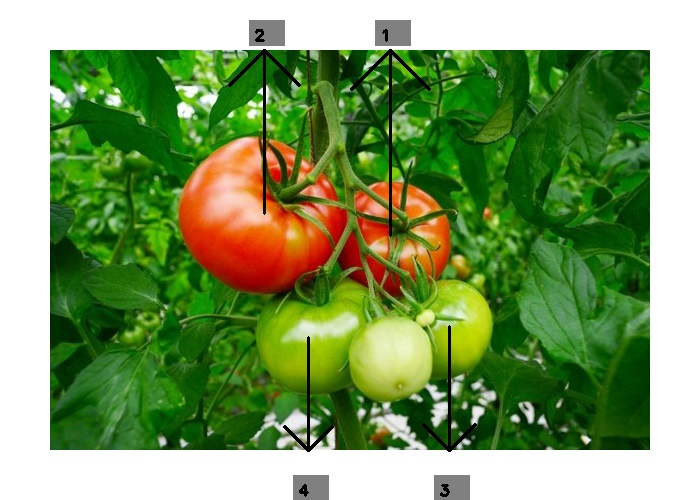

In [21]:
# second detection - selectively
def _normalized_list(xs):
    return sorted([x.strip().lower() for x in xs if x and x.strip()])

if _normalized_list(refined_concept_list) != _normalized_list(initial_query_list) and len(refined_concept_list) > 0:
    print("refined list differs → running second pass...")
    detected_refined, labeled_refined_path = detector._run_detector(image_path, refined_concept_list)
    print(f"second-pass detections: {len(detected_refined)}")

    # 최종 사용 결과 선택 (2차가 유의미하면 교체)
    second_detections = detected_refined
    second_labeled = labeled_refined_path
else:
    print("refinement not needed or identical → keep first pass.")
    second_detections = initial_query_list
    second_labeled = labeled_image_path

# 상세 결과 출력
print("\n[Second detections]:")
for num, label, bbox in second_detections:
    x1, y1, x2, y2 = bbox
    print(f"  [{num}] label: {label} | box: ({x1:.1f}, {y1:.1f}, {x2:.1f}, {y2:.1f})")

try:
    display(Image.open(second_labeled))
except:
    pass

In [22]:
# === Critique/Refine ===
# “너무 구체/오분류 라벨→상위 개념 일반화”를 요청

def _critique_and_refine_query(self, user_request, original_concepts, labeled_image_path, objects_detected, model = 'gpt-4o'):
    """
    input: annotated image, user_request, initial detection
    output: refined concept
    """
    try: 
        # === image encoding ===
        base64_labeled_image = encode_image_to_base64(labeled_image_path)
        if not base64_labeled_image:
            return None
        
        # === refined_messages ===
        refined_messages = [
            {
                "role": "system", 
                "content": """
                    You are an AI system that refines detection queries. 
                    You are provided with the outputs from an object detection model, along with the user's request and the objects from the user's request that were extracted and provided to the object detection model.
                    Your task is to analyze whether the object detector has extracted the results properly to the user's request and, if not, refine the queries by generalizing concepts where possible.
                    
                    Important guidelines:
                    1. If the detection results are already good, no need to refine. 
                    - In that case, provide reasoning indicating no refinement was necessary and return the same list.
                    2. If the detection results are poor or null, propose synonyms or more generic categories and explain why. Wherever possible, retain the singular version of the concept.
                    3. Return your final answer as a JSON object with exactly two fields: "reasoning" and "refined_list".
                    - "reasoning" is a short explanation of why you refined or didn't refine.
                    - "refined_list" is a comma-separated list of object names that should be re-tried in detection.
                    4. Output ONLY the JSON, and no other text.

                    Below are some examples:

                    EXAMPLE 1
                    User's Request: Detect the teacup poodle
                    Original concept: "Teacup poodle"

                    Final output:
                    {
                    "reasoning": "The provided image does not have any detections for the concept of teacup poodle. The concept "teacup poodle" might be a very specific concept for the model to detect. This could  be refined to a more higher-level and generic concept like 'Dog',
                    "refined_list": "dog"
                    }

                    EXAMPLE 2
                    User's Request: Detect the sparkly stiletto shoe
                    Original concept: "Sparkly stiletto shoe"

                    Final output:
                    {
                    "reasoning": "The provided image does not specific detections that correspond for 'Sparkly stiletto shoe'. 'Sparkly stiletto shoe' might be too specific for the model. Refining to 'shoe', a more generic concept might increase the likelihood of detection.",
                    "refined_list": "shoe"
                    }

                    EXAMPLE 3
                    User's Request: Detect the hydrangea
                    Original concept: "Hydrangea"

                    Final output:
                    {
                    "reasoning": "No detections found for 'hydrangea'. The model might struggle with specific flower types. Refining to the more general concept 'flower' could yield better results.",
                    "refined_list": "flower"
                    }

                    EXAMPLE 4
                    User's Request: Detect the gourmet cheeseburger
                    Original concept: "Gourmet cheeseburger"

                    Final output:
                    {
                    "reasoning": "No detections observed for 'Gourmet cheeseburger'. 'Gourmet cheeseburger' might be too specific. Refining to 'hamburger' as it aligns with the detected object.",
                    "refined_list": "hamburger"
                    }

                    EXAMPLE 5
                    User's Request: Detect the red sports car
                    Original concept: "Red sports car"

                    Final output:
                    {
                    "reasoning": "The provided image does not have any reliable detections for 'red sports car'. Color-based detection might be challenging. Refining to the more general concept 'car' could improve detection.",
                    "refined_list": "car"
                    }

                    EXAMPLE 6
                    User's Request: Find all the tomatoes on the vine
                    Original concept: "Tomatoes on the vine"

                    Final output:
                    {
                    "reasoning": "The model might not understand the composite concept 'tomatoes on the vine'. It's better to detect the primary object. Refining to 'tomato' will likely yield better results.",
                    "refined_list": "tomato"
                    }

                    Remember: 
                    • If no refinement is needed (the concept is recognized well), explain that in the reasoning and return the same concept. 
                    • When refinement is necessary, prioritize more generic or abstract categories that may be more reliably detected by the model.
                    • Provide only the JSON. 
                    • No extra commentary.
                    """
            }, 
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": f"User's request: {user_request}\n Original Concepts for Detection: {original_concepts}"},
                    {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{base64_labeled_image}", "detail": "high"}}
                ]
            }
        ]

        # === VLM 응답 결과 ===
        refined_result = self.vlm_tool.model_response(refined_messages, model=model, response_format={"type": "json_object"})
        refined_response_object = json.loads(refined_result)["refined_list"].split(",")

        if not refined_response_object:
            return []

        # === 리스트 생성 ====
        refined_list = [obj.strip().lower() for obj in refined_response_object if obj.strip()]
        return refined_list

    except Exception as e:
        print(f"Error extracting objects from request: {e}")
        return None
ObjectDetectionTool._critique_and_refine_query = _critique_and_refine_query

⸻

### 7. Validation

annotated image → VLM: 일괄 batching → 유효한 bbox filtering

* input
    * annotated image
    * user request
* output
    * valid bbox num 

In [23]:
# === 최종 validation ===
# 최종 검증 모델(gpt-4o)에 유효한 객체 번호 제시 -> 최종 박스 좌표 출력

def _validate_bboxes_with_llm_debuging(self, user_request, labeled_image_path, model="gpt-41"):
    """
    input: annotated image, userrequest
    output: valid bbox number
    """
    # === image encoding ===
    base64_labeled_image = encode_image_to_base64(labeled_image_path)
    if not base64_labeled_image:
        return None
    
    # === validate messages ===
    validate_messages = [
        {
            "role": "system",
            "content": "You are an AI reviewing an object detection output.\n"
                        "All detected objects have been marked with an arrow mapping to a corresponding number.\n"
                        "The image contains arrows labeled with numbers pointing to specific objects.\n"
                        "Your task is to identify the objects indicated by these arrows and determine whether each detected object is relevant to the user's query.\n"
                        "For each numbered arrow:\n"
                        "1. Identify the object being pointed to.\n"
                        "2. Provide a brief description of the object (e.g., 'top-left cup with blue leaves', 'bottom-right cup with watermelon pattern', or 'background birdcage').\n"
                        "3. Analyze whether the object is valid based on the context and the user's instructions.\n"
                        "4. Provide a clear, step-by-step explanation for each object's validity decision.\n"                                          
                        "Return a JSON object with the reasoning and list of valid numbers matching the user's request.\n"
                        "Example output:\n"
                        "{ \"reasoning\": <reasoning> , \"valid_numbers\": {object_num :\"object_name\"} }"
        },
        {
            "role": "user",
            "content": [
                {"type": "text", "text": f"User's request: {user_request}"},
                {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{base64_labeled_image}", "detail": "high"}}
            ]
        }
    ]
    
    # === VLM 응답 결과 ===
    valid_numbers_json = self.vlm_tool.model_response(validate_messages, model=model, response_format={"type": "json_object"})
    
    print("[Raw LLM Response]:")
    print(valid_numbers_json)  # Raw JSON 문자열 그대로 출력

    # === Parse JSON ===
    try:
        valid_numbers_data = json.loads(valid_numbers_json)
        reasoning = valid_numbers_data.get("reasoning", "")
        valid_numbers = valid_numbers_data.get("valid_numbers", {})

        print("\n[Parsed LLM Validation Result]")
        print("Reasoning:", reasoning)
        print("Valid Numbers (with labels):")
        for num, label in valid_numbers.items():
            print(f" - {num}: {label}")

        return valid_numbers
    
    except json.JSONDecodeError as e:
        return {}
ObjectDetectionTool._validate_bboxes_with_llm_debuging = _validate_bboxes_with_llm_debuging

Example

In [24]:
# === VLM Validation ===
valid_numbers = detector._validate_bboxes_with_llm_debuging(
    user_request=user_request,
    labeled_image_path=second_labeled,
    model=detector.final_critique_model
)
print(" ")
print(f"[Valid object numbers]: {valid_numbers}")


[Raw LLM Response]:
{
  "reasoning": 
  "The user's request is to find red colored tomatoes in the image. Let's analyze each numbered arrow:\n\n1. Arrow 1 points to a tomato that is mostly red in color. This matches the user's request for red colored tomatoes.\n2. Arrow 2 points to another tomato that is also red in color. This is valid as it matches the user's request.\n3. Arrow 3 points to a tomato that is green in color. This does not match the user's request for red colored tomatoes, so it is not valid.\n4. Arrow 4 points to another tomato that is greenish-yellow in color. This also does not match the user's request for red colored tomatoes, so it is not valid.\n\nTherefore, only the tomatoes indicated by arrows 1 and 2 are valid for the user's request.",
  "valid_numbers": {
    "1": "top-center red tomato",
    "2": "top-left red tomato"
  }
}

[Parsed LLM Validation Result]
Reasoning: The user's request is to find red colored tomatoes in the image. Let's analyze each numbered ar


[Final validated detections]: 2 objects

[FINAL RESULTS]
  [1] top-center red tomato
       BBox: (269.2, 125.2) → (412.6, 245.0)
       Size: 143.4 × 119.8

  [2] top-left red tomato
       BBox: (127.9, 83.8) → (301.8, 244.8)
       Size: 173.9 × 161.0

[Validated objects]: top-center red tomato, top-left red tomato

[Annotated Image with Validated Bounding Boxes]:


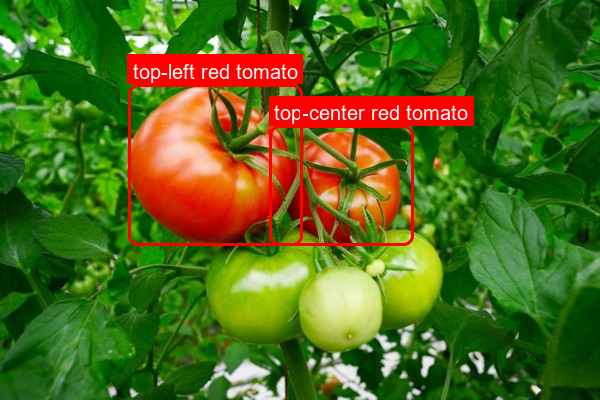

In [25]:
if valid_numbers: 
    # VLM이 유효하다고 판단한 객체만 필터링
    filtered_objects = [
        (num, valid_numbers[str(num)], box) 
        for (num, label, box) in second_detections 
        if str(num) in valid_numbers
    ]
else:
    # VLM validation 실패 시 모든 detection 사용
    filtered_objects = second_detections

print(f"\n[Final validated detections]: {len(filtered_objects)} objects")

# === Produce final annotated image (piepline.ipynb 69번 줄) ===
final_img = draw_bounding_boxes(image_path, filtered_objects)


# === 결과 출력 ===
print("\n" + "="*60)
print("[FINAL RESULTS]")
print("="*60)
for num, label, bbox in filtered_objects:
    x1, y1, x2, y2 = bbox
    print(f"  [{num}] {label}")
    print(f"       BBox: ({x1:.1f}, {y1:.1f}) → ({x2:.1f}, {y2:.1f})")
    print(f"       Size: {x2-x1:.1f} × {y2-y1:.1f}")
    print()

# Final summary text (piepline.ipynb 71-73번 줄)
validated_labels = ', '.join(set(str(lbl) for _, lbl, _ in filtered_objects))
print(f"[Validated objects]: {validated_labels}")
print("="*60)

# === 시각화 ===
print("\n[Annotated Image with Validated Bounding Boxes]:")
display(final_img)

In [26]:
# === 최종 validation ===
# 최종 검증 모델(gpt-4o)에 유효한 객체 번호 제시 -> 최종 박스 좌표 출력

def _validate_bboxes_with_llm(self, user_request, labeled_image_path, model="gpt-41"):
    """
    input: annotated image, userrequest
    output: valid bbox number
    """
    # === image encoding ===
    base64_labeled_image = encode_image_to_base64(labeled_image_path)
    if not base64_labeled_image:
        return None
    
    # === validate messages ===
    validate_messages = [
        {
            "role": "system",
            "content": "You are an AI reviewing an object detection output.\n"
                        "All detected objects have been marked with an arrow mapping to a corresponding number.\n"
                        "The image contains arrows labeled with numbers pointing to specific objects.\n"
                        "Your task is to identify the objects indicated by these arrows and determine whether each detected object is relevant to the user's query.\n"
                        "For each numbered arrow:\n"
                        "1. Identify the object being pointed to.\n"
                        "2. Provide a brief description of the object (e.g., 'top-left cup with blue leaves', 'bottom-right cup with watermelon pattern', or 'background birdcage').\n"
                        "3. Analyze whether the object is valid based on the context and the user's instructions.\n"
                        "4. Provide a clear, step-by-step explanation for each object's validity decision.\n"                                          
                        "Return a JSON object with the reasoning and list of valid numbers matching the user's request.\n"
                        "Example output:\n"
                        "{ \"reasoning\": <reasoning> , \"valid_numbers\": {object_num :\"object_name\"} }"
        },
        {
            "role": "user",
            "content": [
                {"type": "text", "text": f"User's request: {user_request}"},
                {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{base64_labeled_image}", "detail": "high"}}
            ]
        }
    ]
    
    # === VLM 응답 결과 ===
    valid_numbers_json = self.vlm_tool.model_response(validate_messages, model=model, response_format={"type": "json_object"})


    # === Parse JSON ===
    try:
        valid_numbers_data = json.loads(valid_numbers_json)
        reasoning = valid_numbers_data.get("reasoning", "")
        valid_numbers = valid_numbers_data.get("valid_numbers", {})

        return valid_numbers
    
    except json.JSONDecodeError as e:
        return {}
ObjectDetectionTool._validate_bboxes_with_llm = _validate_bboxes_with_llm


⸻

### 8. Final pipeline


1. label 변화 O
    * Concept detector →  Objection detector + Visualization → Refined detection → Final filtering + visualization    
2. label 변화 x
    * Concept detector → Final filtering + visualization    

In [27]:
def run(self, image_path, user_request, do_critique=True):
    """
        Full pipeline:
        1. Extract objects from user request (LLM).
        2. Detect bounding boxes with that query.
        3. (Optional) Critique Step => refine the query if needed.
        4. (Optional)Re-run detection with refined queries.
        5. Final LLM validation => final bounding boxes and annotation.
    """
    # === 1. initial user request → object list ===
    objects_to_detect = self.vlm_tool.extract_objects_from_request(image_path, user_request, model=self.concept_detection_model)
    if not objects_to_detect:
        return None, "No objects to detect or invalid request."

    # === 2. initial detection ===
    detected_objects_initial, labeled_image_path = self._run_detector(image_path, objects_to_detect)

    # === 3. critique & refine ===
    if do_critique:
        current_labels = ",".join(set([str(lbl) for _, lbl, _ in detected_objects_initial]))

        refined_query_list = self._critique_and_refine_query(
            user_request=user_request,
            original_concepts=current_labels,
            labeled_image_path=labeled_image_path,
            objects_detected=current_labels,
            model=self.initial_critique_model
        )

        if refined_query_list and set(refined_query_list) != set(objects_to_detect):
            detected_objects_final, labeled_image_path = self._run_detector(image_path, refined_query_list)
            if not detected_objects_final:
                return None, "No objects found for the initial query."
        
    # === 4. validation ===
    # dictionary 형태의 유효한 객체 번호 목록
    valid_numbers = self._validate_bboxes_with_llm(user_request, labeled_image_path, model=self.final_critique_model)
    
    # filter bounding boxes
    if valid_numbers: 
        filtered_objects = [(n, valid_numbers[str(n)], box) for (n, lbl, box) in detected_objects_final if str(n) in valid_numbers]
        # detection에서 유효한 객체 번호 목록에 따른 detection 박스에 대한 튜플만 걸러내기 
    else:
        filtered_objects = detected_objects_final

    # store
    self.last_detection_bboxes = [x[-1] for x in filtered_objects] # 튜플의 마지막 항목 - bbox 좌표 리스트
    self.last_filtered_objects = filtered_objects

    # === 5. Produce final annotated image ===
    final_img = draw_bounding_boxes(image_path, filtered_objects)
    final_text = (
        f"Validated objects: {', '.join(set(str(lbl) for _, lbl, _ in filtered_objects))}"
    )
    return final_img, final_text

ObjectDetectionTool.run = run

Full Agentic Detection Pipeline Example

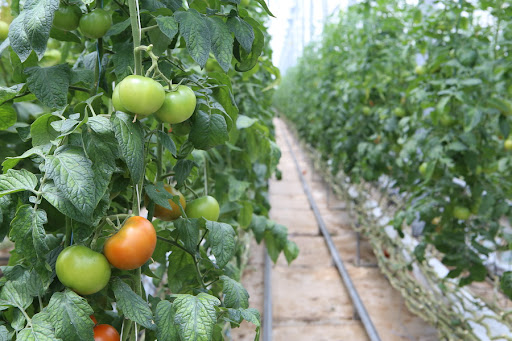

User Request: 'Find the red tomatoes that hidden by leaves'
------------------------------

✅ FINAL RESULT ✅
Validated objects: partially red tomato hidden by leaves


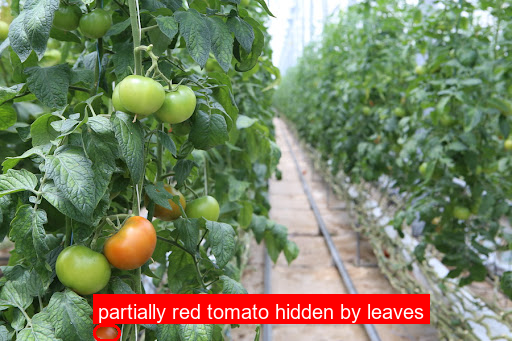

In [37]:
# Define the image path and the complex user request
image_path = r"C:\Users\KIST\agentic-object-detection\data\image1.jpg"
user_request = "Find the red tomatoes that hidden by leaves"


# VLM Tool 초기화
load_dotenv()
api_key = os.getenv("OPENAI_API_KEY")
vlm_tool = VLMTool(api_key=api_key)

# ObjectDetectionTool 초기화
detector = ObjectDetectionTool(
    model_id = MODEL_ID,
    device=DEVICE,
    vlm_tool=vlm_tool,
    confidence_threshold=CONFIDENCE_THRESHOLD,  # 0.2
    concept_detection_model="gpt-4.1",
    initial_critique_model="gpt-4o",
    final_critique_model="gpt-4.1"
)


original_img = Image.open(image_path)
display(original_img)
print(f"User Request: '{user_request}'")
print("-" * 30)

# 2. run
final_image, result_text = detector.run(image_path=image_path, user_request=user_request, do_critique=True)

# 3. Display the final results
print("\n" + "=" * 30)
print("✅ FINAL RESULT ✅")
print("=" * 30)

if final_image:
    print(result_text)
    display(final_image)
else:
    # If the process returns no image, it means no valid objects were found.
    print(result_text)
    print("\nCould not find any objects matching the request after the full process.")
    # Display the original image for context
    print("Original Image:")
    display(Image.open(image_path))


⸻

### Experiment

In [ ]:
# 개념 추출이 “명시 vs 나열” 모두 잘 동작하는지
# 1차 탐지 → 비평 → 2차 탐지가 있을 때 성능이 개선되는지
# 숫자 배칭 한 번만으로 모든 박스를 검증 가능(박스별 크롭을 다수 요청하는 것보다 효율적)함을 확인


In [40]:
# ========================================
# 실험 1: 개념 추출 테스트 (명시 vs 나열)
# ========================================

print("="*60)
print("실험 1: 개념 추출 - 명시 vs 나열")
print("="*60)

# VLM Tool 초기화
load_dotenv()
api_key = os.getenv("OPENAI_API_KEY")
vlm_tool = VLMTool(api_key=api_key)

test_image = input_img_path

# 테스트 케이스 1: 명시적 요청 (specific object)
user_request_specific = "Find the red tomatoes in this image."
print(f"\n[Test 1-A] 명시적 요청: '{user_request_specific}'")
concepts_specific = vlm_tool.extract_objects_from_request(test_image, user_request_specific)
print(f"  → 추출된 개념: {concepts_specific}")

# 테스트 케이스 2: 나열 요청 (list all objects)
user_request_list = "Find all visible objects in this image."
print(f"\n[Test 1-B] 나열 요청: '{user_request_list}'")
concepts_list = vlm_tool.extract_objects_from_request(test_image, user_request_list)
print(f"  → 추출된 개념: {concepts_list}")

# 결과 비교
print("\n" + "="*60)
print("결과 비교:")
print(f"  명시적: {len(concepts_specific)}개 개념 추출")
print(f"  나열형: {len(concepts_list)}개 개념 추출")

실험 1: 개념 추출 - 명시 vs 나열

[Test 1-A] 명시적 요청: 'Find the red tomatoes in this image.'
  → 추출된 개념: ['red tomatoes']

[Test 1-B] 나열 요청: 'Find all visible objects in this image.'
  → 추출된 개념: ['red tomato', 'green tomatoes', 'tomato vine', 'leaves']

결과 비교:
  명시적: 1개 개념 추출
  나열형: 4개 개념 추출


In [ ]:
# ========================================
# 실험 2: 1차 탐지 vs 2차 탐지 성능 비교
# ========================================

print("\n\n" + "="*60)
print("실험 2: 1차 탐지 vs 비평 후 2차 탐지 성능 비교")
print("="*60)

# Detector 초기화
detector = ObjectDetectionTool(
    model_id=MODEL_TYPES["owlvit"],
    device=DEVICE,
    vlm_tool=vlm_tool,
    confidence_threshold=CONFIDENCE_THRESHOLD,
    concept_detection_model="gpt-4.1",
    initial_critique_model="gpt-4o",
    final_critique_model="gpt-4.1"
)

# 테스트 이미지 및 요청
test_image = input_img_path
user_request = "Find red tomatoes in this image."

# VLM 개념 추출
initial_concepts = vlm_tool.extract_objects_from_request(test_image, user_request)
print(f"\n[Step 1] 초기 개념 추출: {initial_concepts}")

# 1차 탐지
print(f"\n[Step 2] 1차 탐지 시작...")
detected_1st, labeled_1st = detector._run_detector(test_image, initial_concepts)
print(f"  → 1차 탐지 결과: {len(detected_1st)}개 객체")

# VLM 비평 및 개념 정제
print(f"\n[Step 3] VLM 비평 및 개념 정제...")
refined_concepts = detector._critique_and_refine_query(
    user_request=user_request,
    original_concepts=initial_concepts,
    labeled_image_path=labeled_1st,
    objects_detected=detected_1st,
    model="gpt-4o"
)
print(f"  → 정제된 개념: {refined_concepts}")

# 2차 탐지 (정제된 개념 사용)
if refined_concepts != initial_concepts:
    print(f"\n[Step 4] 2차 탐지 시작 (정제된 개념 사용)...")
    detected_2nd, labeled_2nd = detector._run_detector(test_image, refined_concepts)
    print(f"  → 2차 탐지 결과: {len(detected_2nd)}개 객체")
    
    # 성능 비교
    print("\n" + "="*60)
    print("성능 비교:")
    print(f"  1차 탐지: {len(detected_1st)}개 객체 (개념: {initial_concepts})")
    print(f"  2차 탐지: {len(detected_2nd)}개 객체 (개념: {refined_concepts})")
    improvement = len(detected_2nd) - len(detected_1st)
    if improvement > 0:
        print(f" 성능 개선: +{improvement}개 객체 추가 탐지")
    elif improvement < 0:
        print(f" 객체 수 감소: {improvement}개 (더 정확한 결과일 수 있음)")
    else:
        print(f" 개념만 변경됨")
    print("="*60)
else:
    print(f"\n 개념이 동일하여 2차 탐지 생략")



실험 2: 1차 탐지 vs 비평 후 2차 탐지 성능 비교

[Step 1] 초기 개념 추출: ['red tomatoes']

[Step 2] 1차 탐지 시작...
  → 1차 탐지 결과: 4개 객체

[Step 3] VLM 비평 및 개념 정제...
  → 정제된 개념: ['tomato']

[Step 4] 2차 탐지 시작 (정제된 개념 사용)...
  → 2차 탐지 결과: 4개 객체

성능 비교:
  1차 탐지: 4개 객체 (개념: ['red tomatoes'])
  2차 탐지: 4개 객체 (개념: ['tomato'])
 객체 수 동일 (개념만 변경됨)
